<a href="https://colab.research.google.com/github/MidhulaMS/EV-Population-Prediction/blob/Aswin.eda_and_preprocessing/EV_Population_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For evaluating Mode
from statistics import mode

# Mutual Information: Target is salary which is continous
from sklearn.feature_selection import mutual_info_regression

# For min max scaling
from sklearn.preprocessing import MinMaxScaler

# Reading Data

In [ ]:
filepath = "/content/drive/MyDrive/ICT/Project Work/export (1).csv"

In [ ]:
EV_df = pd.read_csv(filepath)

## Exploratory data analysis (EDA)


In [ ]:
EV_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287763 entries, 0 to 287762
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         287763 non-null  object 
 1   County                                             287754 non-null  object 
 2   City                                               287754 non-null  object 
 3   State                                              287763 non-null  object 
 4   Postal Code                                        287754 non-null  float64
 5   Model Year                                         287763 non-null  int64  
 6   Make                                               287763 non-null  object 
 7   Model                                              287763 non-null  object 
 8   Electric Vehicle Type                              287763 non-null  object

In [15]:
EV_df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10


In [16]:
# Numerical Data - Electric Range
# Categorical Data - County,City,State,postal code,Make,Model,ElectricVehicleType,Model Year,CAFV,Eligibility,Electric Utility,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
# Identifiers- VIN,DOL Vehicle ID

In [17]:
EV_df.shape

(287763, 16)

In [18]:
EV_df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,287754.000000,287763.000000,287754.000000,287023.000000,2.877630e+05,2.877540e+05
mean,98174.889729,2022.207299,37.828697,28.849608,2.486886e+08,5.296750e+10
std,2638.364484,3.075325,77.223589,14.889125,6.293818e+07,1.691737e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.258425e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.658514e+08,5.303303e+10
75%,98387.000000,2024.000000,32.000000,42.000000,2.820231e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [19]:
# Electric Range minimum value is "0" which needs to be inspected.

In [20]:
EV_df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

### finding missing values

In [ ]:
EV_df.isna().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [ ]:
EV_df.duplicated().sum()

np.int64(0)

In [34]:
EV_df['Electric Vehicle Type'].unique()

array(['Plug-in Hybrid Electric Vehicle (PHEV)',
       'Battery Electric Vehicle (BEV)'], dtype=object)

In [21]:
EV_df.nunique()

,0
VIN (1-10),17690
County,256
City,931
State,53
Postal Code,1166
Model Year,23
Make,48
Model,196
Electric Vehicle Type,2
Clean Alternative Fuel Vehicle (CAFV) Eligibility,3


In [23]:
EV_df["Electric Vehicle Type"].value_counts(dropna=False)

,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),232271
Plug-in Hybrid Electric Vehicle (PHEV),55492


In [22]:
EV_df.duplicated().sum()

np.int64(0)

In [25]:
EV_df["Electric Vehicle Type"].isnull().sum()

np.int64(0)

## Visual EDA(Plotting)

In [27]:
numerical_features = [
    "Electric Range"
]

categorical_features = [
    "County",
    "City",
    "State",
    "Postal Code",
    "Model Year",
    "Make",
    "Model",
    "Electric Vehicle Type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    "Legislative District",
    "Electric Utility",
    "Vehicle Location",
    "2020 Census Tract"
]

identifier_features = [
    "VIN (1-10)",
    "DOL Vehicle ID"
]

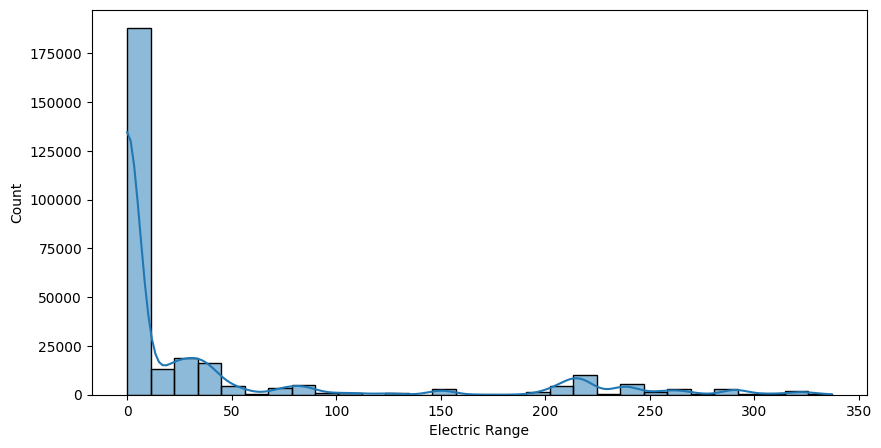

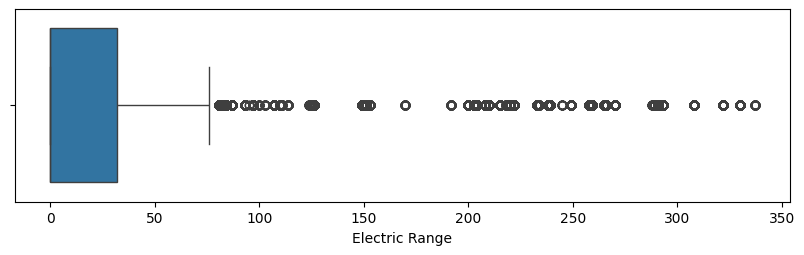

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(EV_df["Electric Range"], kde=True, bins=30)
plt.show()

plt.figure(figsize=(10,2.5))
sns.boxplot(x=EV_df["Electric Range"])
plt.show()

In [37]:
# Data is right skewed since the right whiskers is longer.
# Electric Range contains several high-value outliers.But high range vehicles need to be investigated before treating them as outliers.

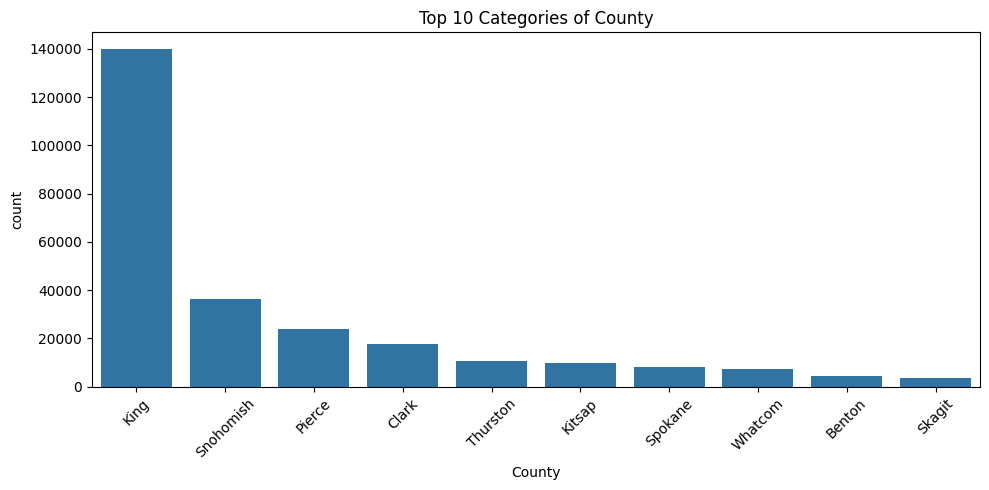

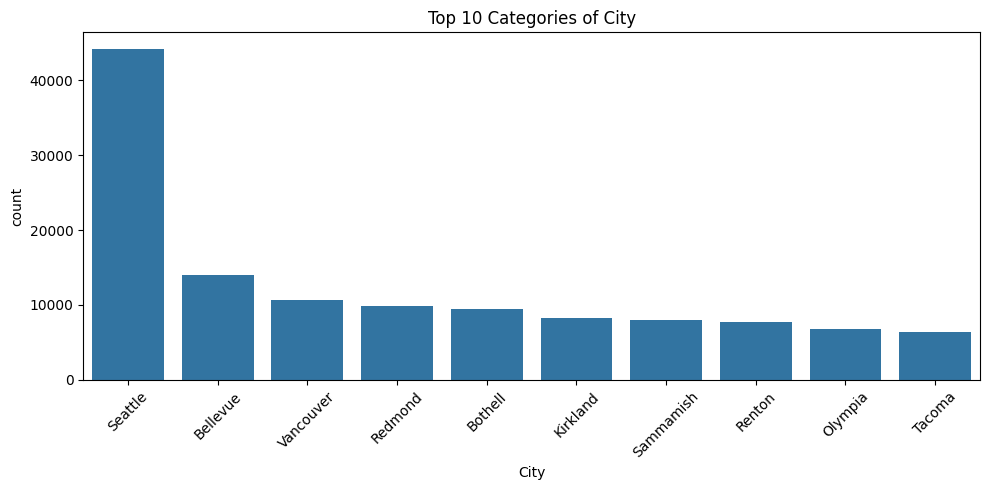

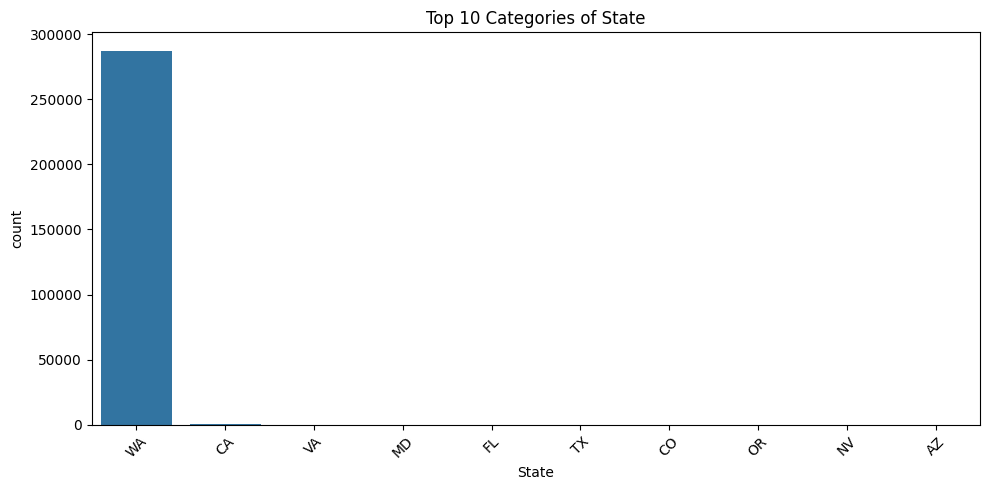

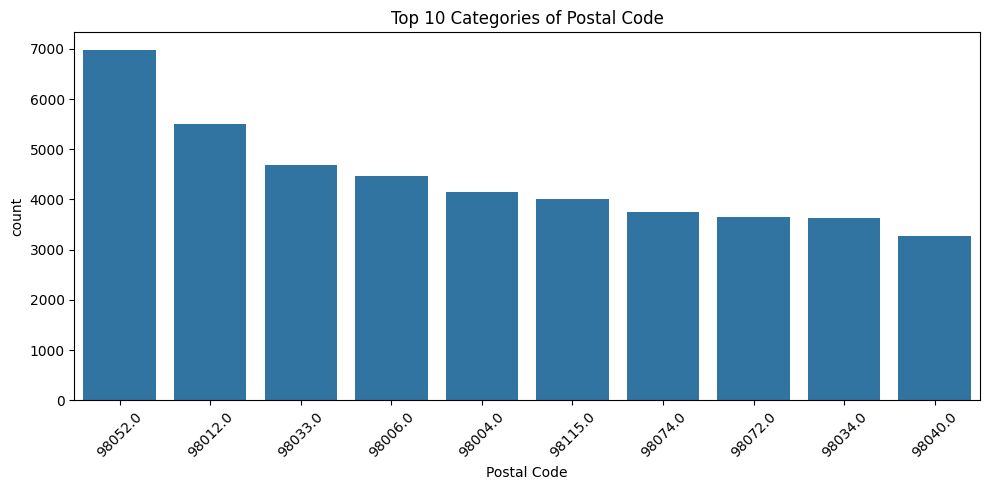

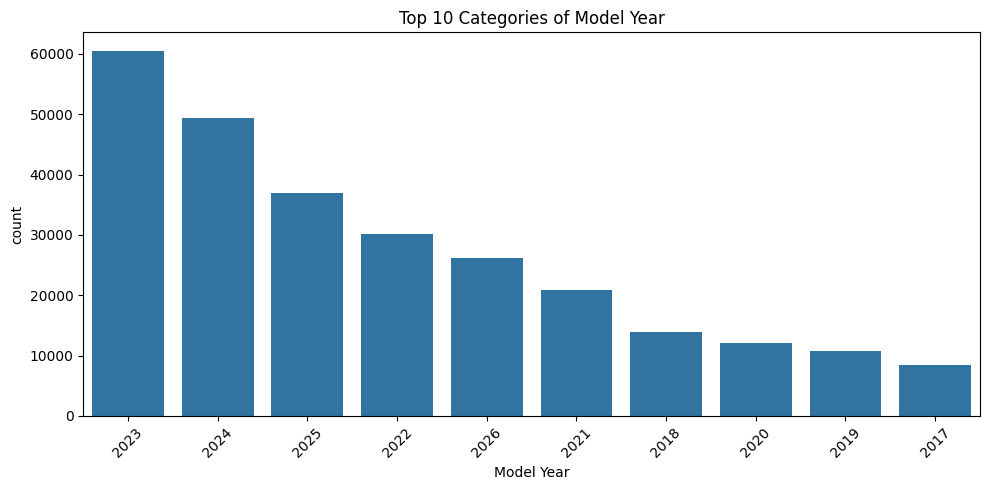

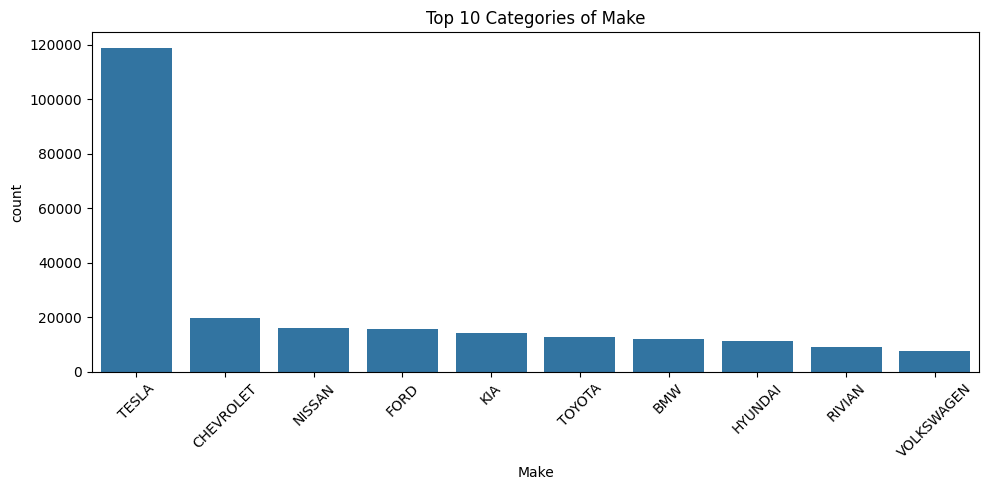

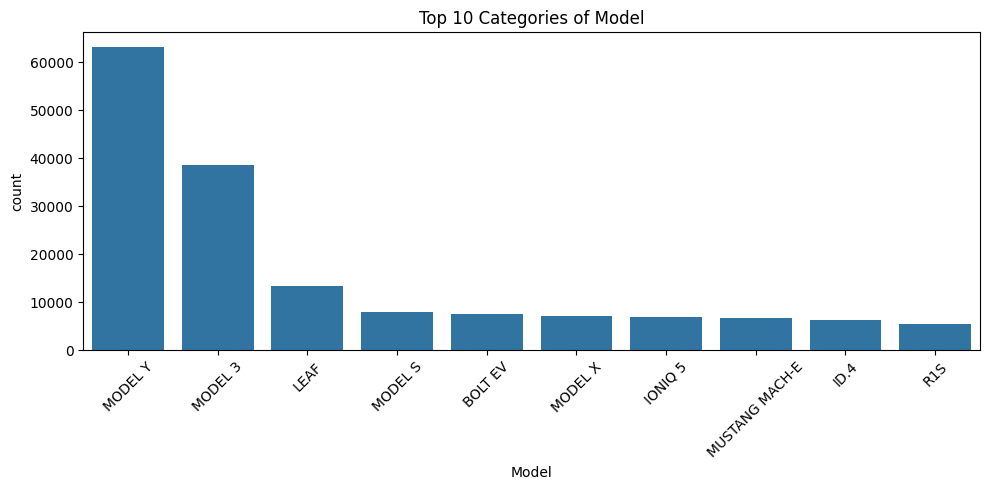

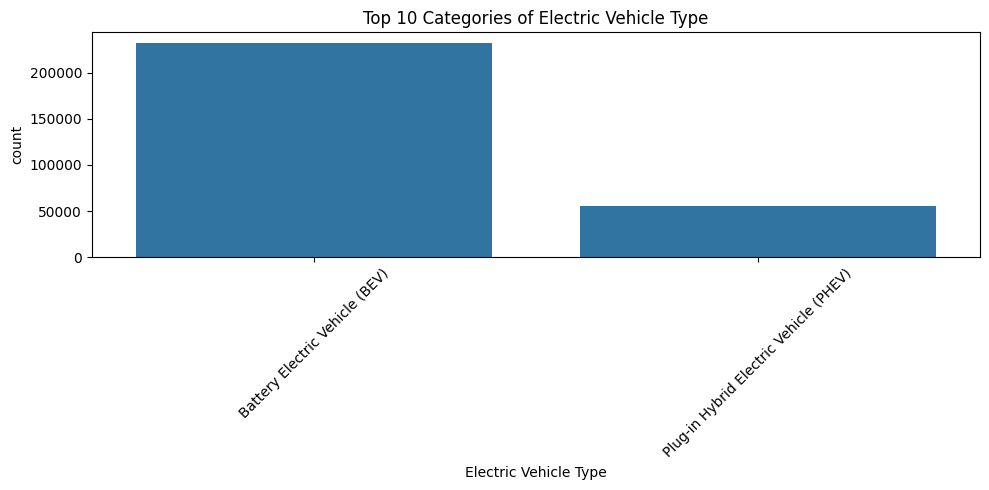

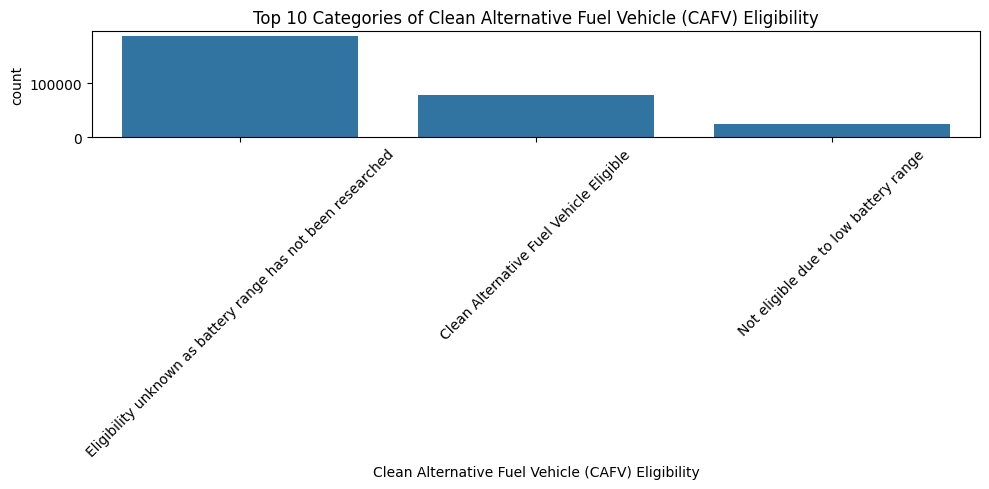

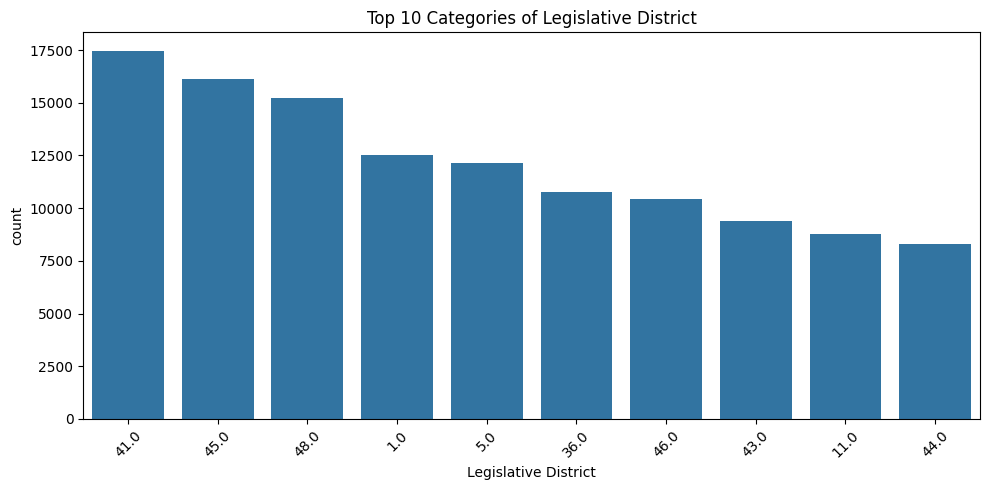

/tmp/ipykernel_1222/2614859388.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


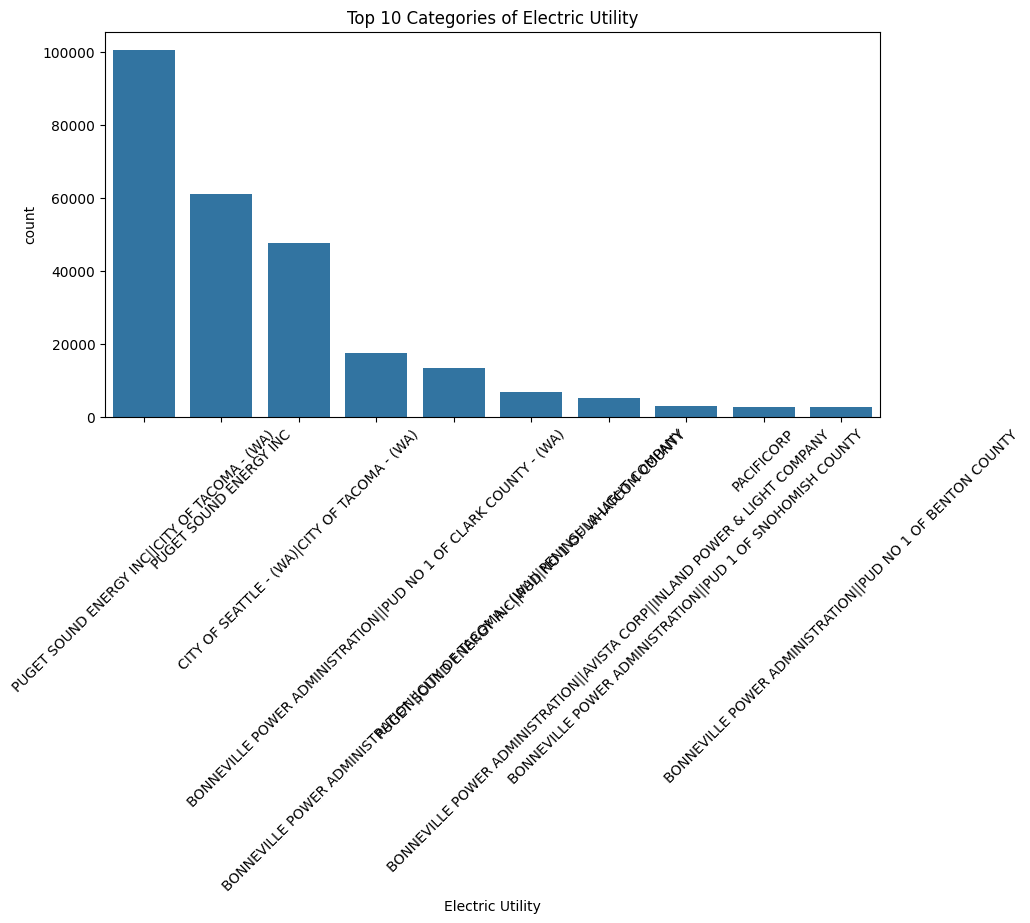

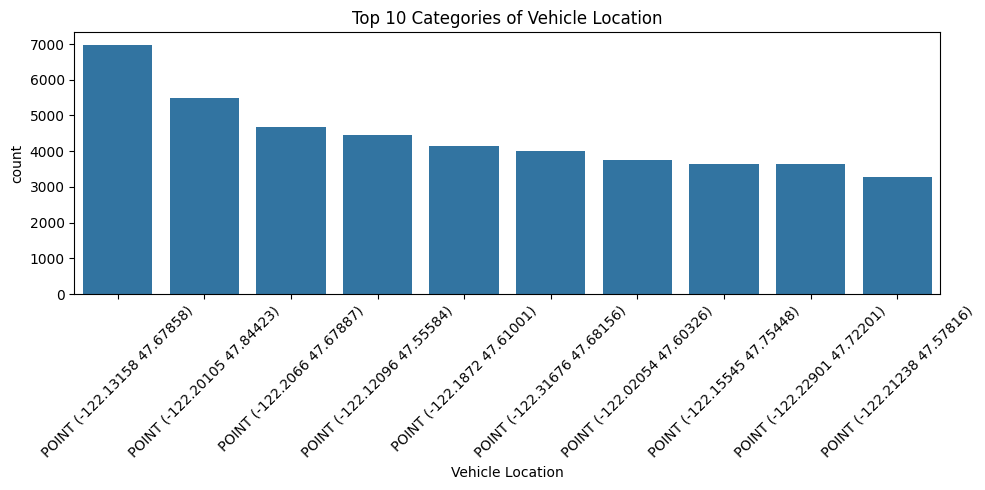

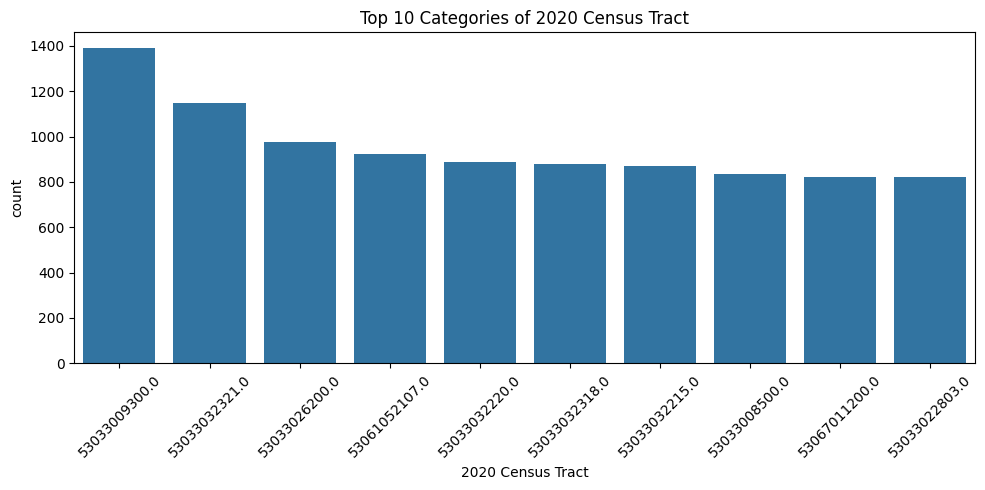

In [30]:
for col in categorical_features:

    plt.figure(figsize=(10,5))

    top10 = EV_df[col].value_counts().head(10).index

    sns.countplot(
        data=EV_df,
        x=col,
        order=top10
    )

    plt.title(f"Top 10 Categories of {col}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [38]:
# From observing Categorical data we understands:
#In 'States' only one state exists this feature has no variation.

### Data Description

# Data preprocessing

## Data Cleaning

### Missing Value Handling

In [ ]:
EV_df.isnull().sum()  #Check missing values

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [ ]:
num_cols = EV_df.select_dtypes(include="number").columns
cat_cols = EV_df.select_dtypes(include="object").columns
num_cols

Index(['Postal Code', 'Model Year', 'Electric Range', 'Legislative District',
       'DOL Vehicle ID', '2020 Census Tract'],
      dtype='object')

In [ ]:
cat_cols

Index(['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model',
       'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location',
       'Electric Utility'],
      dtype='object')

In [ ]:
#Fill missing values in numerical columns using mean
for col in EV_df.select_dtypes(include="number"):
    EV_df[col] = EV_df[col].fillna(EV_df[col].mean())


In [ ]:
#Fill missing values in categorical columns using mode
for col in EV_df.select_dtypes(include="object"):
    EV_df[col] = EV_df[col].fillna(EV_df[col].mode())

### Duplicates Removal

In [ ]:
EV_df.duplicated().sum() #Check duplicates

np.int64(0)

## Outlier Handling

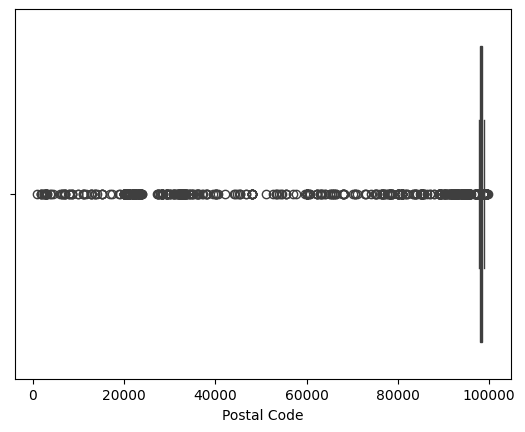

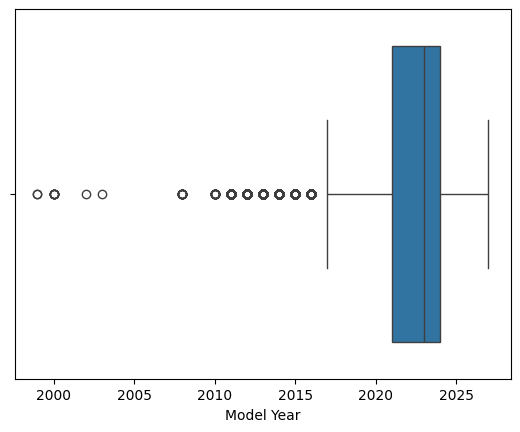

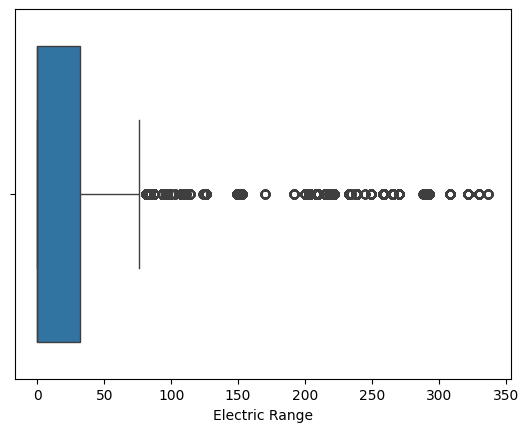

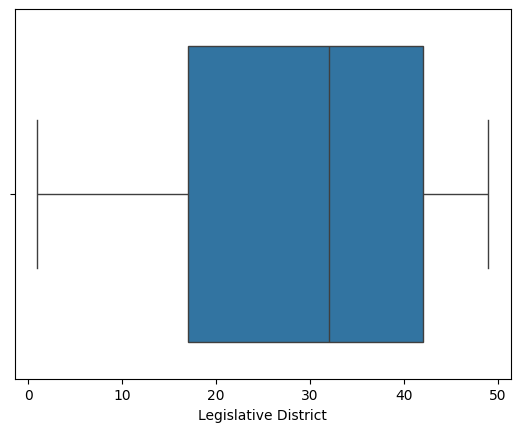

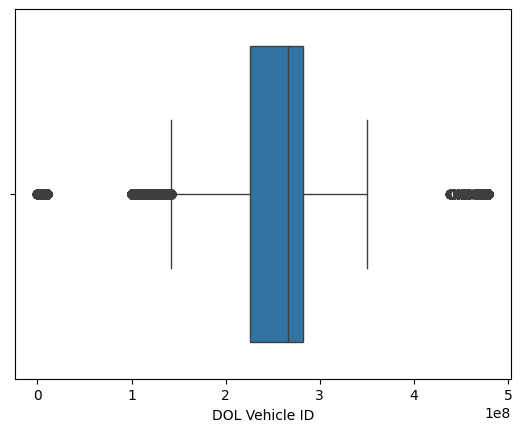

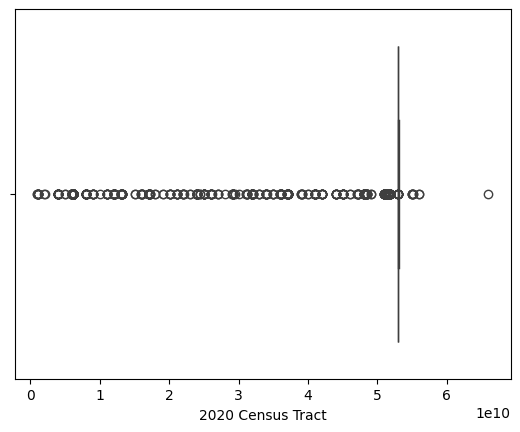

In [ ]:
#outlier detection
for col in EV_df.select_dtypes(include="number"):
    sns.boxplot(x=EV_df[col])
    plt.show()

In [ ]:
for col in EV_df.select_dtypes(include="number"):
    Q1 = EV_df[col].quantile(0.25)
    Q3 = EV_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = EV_df[(EV_df[col] < lower) | (EV_df[col] > upper)]
    print(col, ":", len(outliers))

Postal Code : 20120
Model Year : 18365
Electric Range : 43094
Legislative District : 0
DOL Vehicle ID : 24162
2020 Census Tract : 739


In [ ]:
#outlier removal using iqr method
for col in EV_df.select_dtypes(include="number"):
    Q1 = EV_df[col].quantile(0.25)
    Q3 = EV_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    EV_df = EV_df[(EV_df[col] >= lower) & (EV_df[col] <= upper)]
    EV_df.head()

##UNIVARIATE ANALYSIS :used to clean data, catch anomalies, and determine if features require scaling or transformation prior to modeling

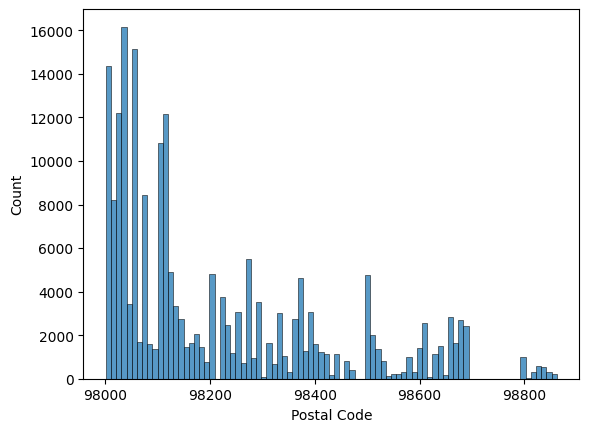

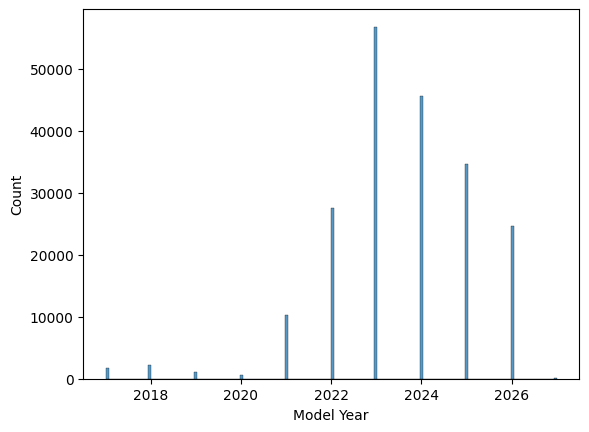

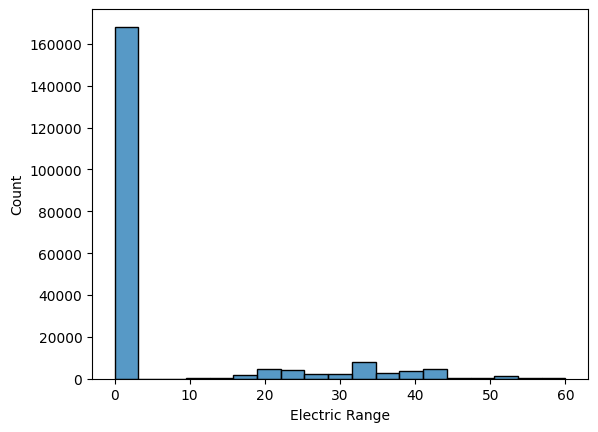

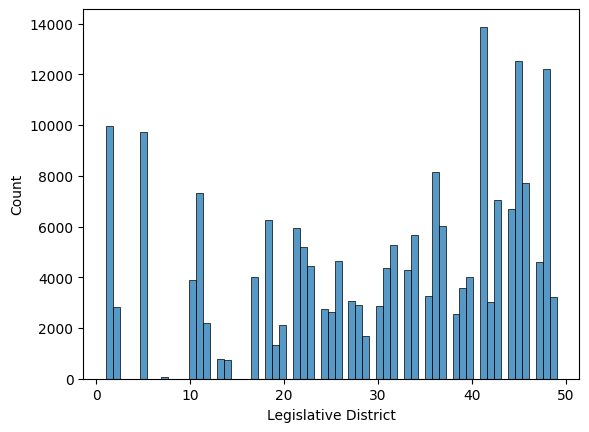

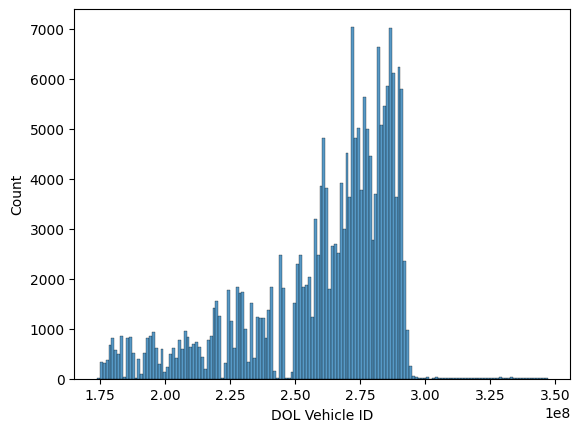

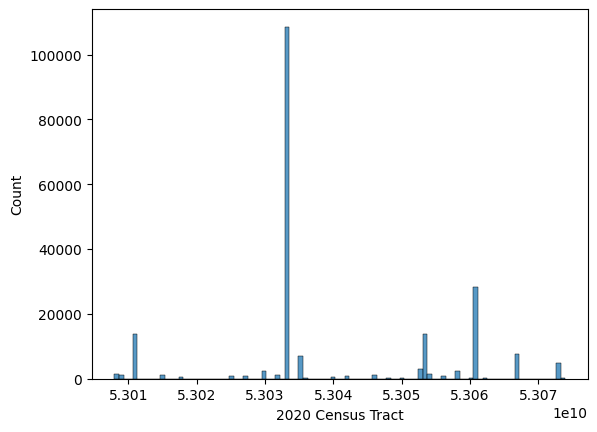

In [ ]:
for cols in EV_df.select_dtypes(include="number"):
  sns.histplot(EV_df[cols])
  plt.show()

###Box plot

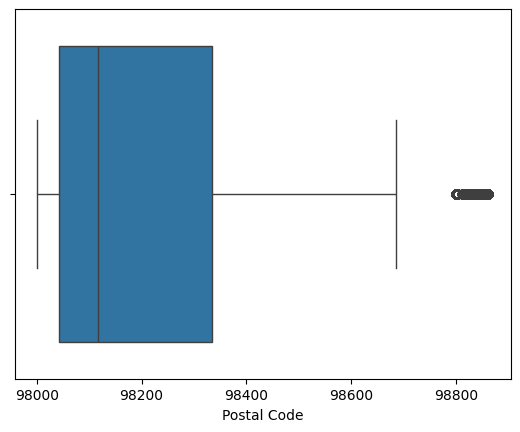

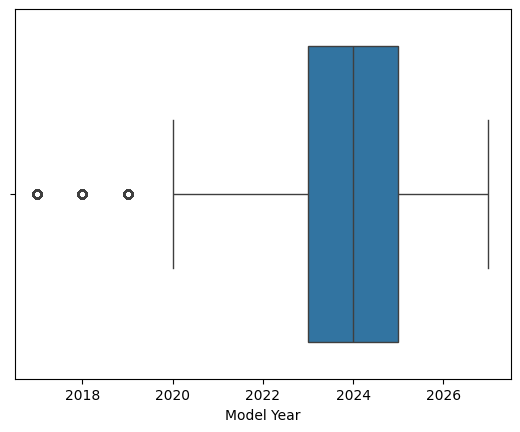

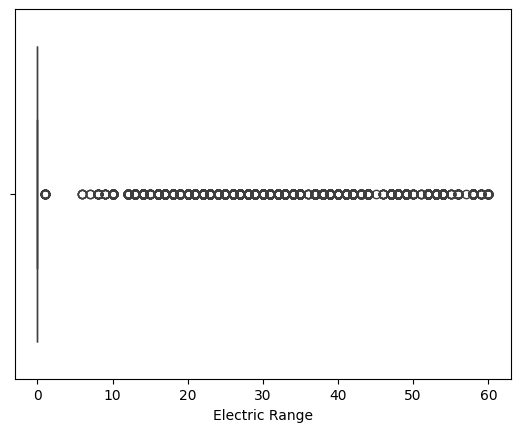

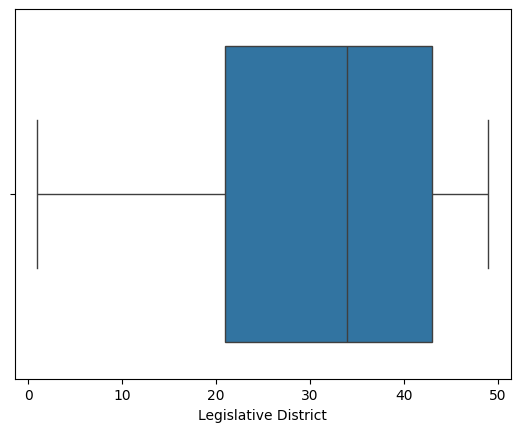

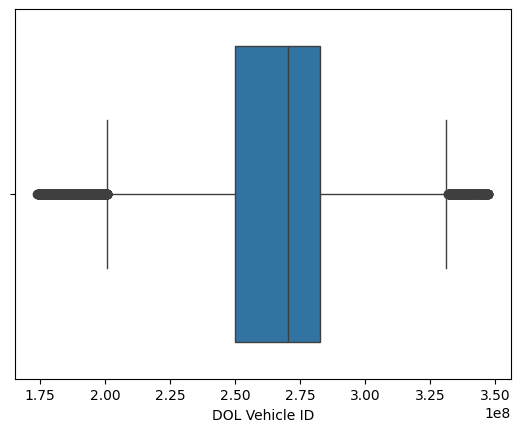

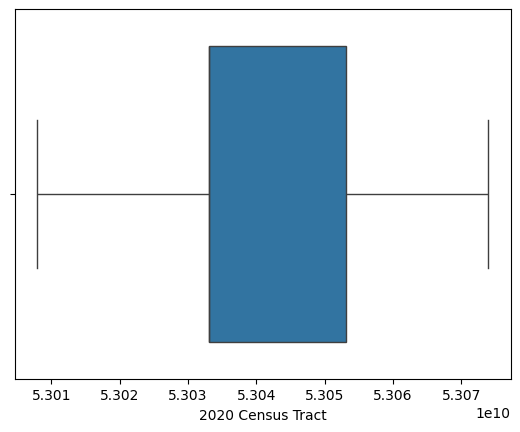

In [ ]:
for col in EV_df.select_dtypes(include="number"):
    sns.boxplot(x=EV_df[col])
    plt.show()

##CORRELATION MATRIX

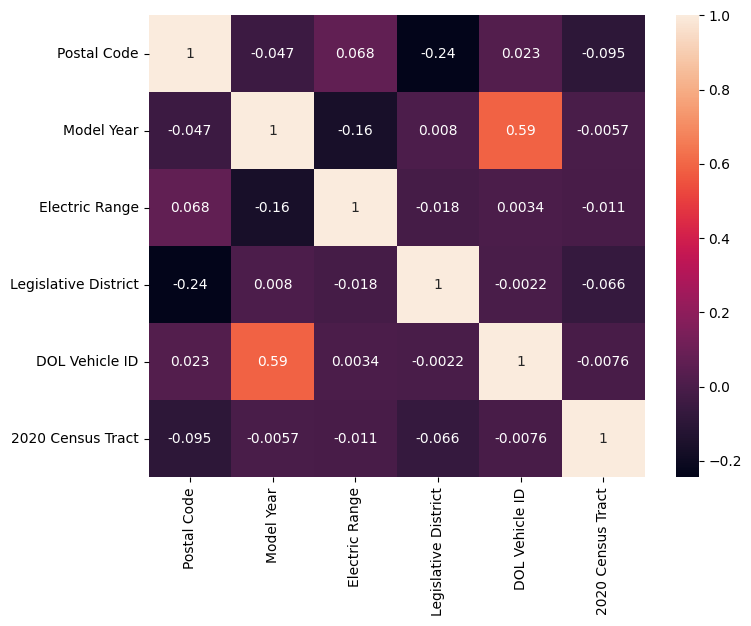

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(EV_df.select_dtypes(include="number").corr(), annot=True)
plt.show()

# Data Transformation

## Scaling

## Encoding

# Data Splitting

# Model Building